## Implied Volatility in Lifted Bergomi model

See full explanation and results in corresponding [doc](../docs/lifted_bergomi_iv.md)

### 1 - Lifted Bergomi Functions

In [2]:
import math
import warnings
import numpy as np
from tqdm import tqdm
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from joblib import Parallel, delayed
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Returns the means reversions x_i
def x(alpha, rn, i, n):
    return ((1 - alpha) * (rn**(2 - alpha) - 1)) / ((2 - alpha) * (rn**(1 - alpha) - 1)) * rn**(i - 1 - n / 2)

# Returns the weights c_i
def c(alpha, rn, i, n):
    return ((rn**(1 - alpha) - 1) / (math.gamma(alpha) * math.gamma(2 - alpha))) * rn**((1 - alpha) * (i - 1 - n / 2))

# Return the trajectories of the Lifted Bergomi model (V,S)
def Sim_Lifted_Bergomi(n,T,H,eta,ksi,rho,M,alpha,rn,S0):
    dt = T/M
    Y = np.zeros((n,M))
    V = []
    S = [S0]
    Kn = []
    dW = np.sqrt(dt) * np.random.randn(M)
    xi = np.array([x(alpha, rn, i, n) for i in range(1, n+1)])
    ci = np.array([c(alpha, rn, i, n) for i in range(1, n+1)])

    # Simulation of the Y trajectories
    for k in range(1, M):
        Y[:, k] = Y[:, k-1] - xi * Y[:, k-1] * dt + dW[k]

    # Simulation of K^n and V
    for k in range(M):
        Kn.append(np.sum(ci * np.exp(-xi * k * dt))**2)
        V.append(
            ksi * np.exp(
                eta * math.sqrt(2*H) * math.gamma(H + 0.5) * np.dot(ci, Y[:, k])
                - H * eta**2 * math.gamma(H + 0.5)**2 * np.trapz(Kn, np.linspace(0, T, M)[:k+1])
            )
        )
    
    # Simulation of S
    for k in range(1,M):
        dB = rho * dW[k] + np.sqrt(1 - rho**2) * np.sqrt(dt) * np.random.randn() # Because Bt is correlated to Wt
        log_S = np.log(S[k-1]) - 0.5 * max(V[k-1], 0) * dt + np.sqrt(max(V[k-1], 0)) * dB
        S.append(np.exp(log_S))

    return V,S


### 2 - Options Pricing and Implied Volatility

In [3]:
# Return the approximation of a call option price in the Lifted Bergomi model by Monte-Carlo
def Call_Price_Lifted_Bergomi(S0,K,T,M,nb_scenario,n,H,eta,ksi,rho,alpha,rn):

    C0 = []
    for p in range(nb_scenario):
        V,S = Sim_Lifted_Bergomi(n,T,H,eta,ksi,rho,M,alpha,rn,S0)
        C0.append(max(S[-1]-K,0))
        
    return np.mean(C0)

# Black-Scholes Call Price
def bs_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Implied Volatility using Brent's method
def implied_vol(S0, K, T, r_int, call_price):
    
    # Tests
    intrinsic = max(S0 - K * np.exp(-r_int * T), 0)
    if call_price <= intrinsic + 1e-8:
        return np.nan
    
    upper_price = bs_call(S0, K, T, r_int, sigma=10.0)
    if call_price >= upper_price:
        return np.nan
    
    # Function to find the root 
    def difference_in_prices(sigma):
        return bs_call(S0, K, T, r_int, sigma) - call_price

    return brentq(difference_in_prices, a=1e-6, b=2.5, xtol=1e-6)

### 3 - Implied Vol Lifted Bergomi Long Term

Functions

In [4]:
def compute_single(params, i, j):
    rn = 1 + 10 * params["n"][i] ** (-0.9)
    C0 = Call_Price_Lifted_Bergomi(
        S0=params["S0"], K=params["K"][j], T=params["T"], M=params["M"],
        nb_scenario=params["nb_scenario"], n=params["n"][i], H=params["H"],
        eta=params["eta"], ksi=params["ksi"], rho=params["rho"],
        alpha=params["alpha"], rn=rn
    )
    iv = implied_vol(
        S0=params["S0"], K=params["K"][j], T=params["T"],
        r_int=0, call_price=C0
    )
    return i, j, iv

# Returns Implied Volatility under Lifted Heston model and params
def compute_res(params):
    impl_vol = np.zeros((len(params["n"]), len(params["K"])))

    tasks = [
        (i, j)
        for i in range(len(params["n"]))
        for j in range(len(params["K"]))
    ]

    # Run all tasks in parallel across available CPU cores
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_single)(params, i, j)
        for i, j in tqdm(tasks, desc="Computing Implied Vol")
    )

    for i, j, iv in results:
        impl_vol[i, j] = iv

    return impl_vol

Input:

In [5]:
params = {
    "K": np.exp(np.linspace(-0.6, 0.3, 30)), # Strikes
    "n": [5,10,20], # n factors
    "S0": 1,
    "T": 1,
    "rho": -0.9,
    "lambda": 0.3,
    "ksi": 0.02,
    "alpha": 0.6,
    "M": 252, 
    "H": 0.07,
    "eta": 1.9,
    "nb_scenario": 20000
}

Computation and output:

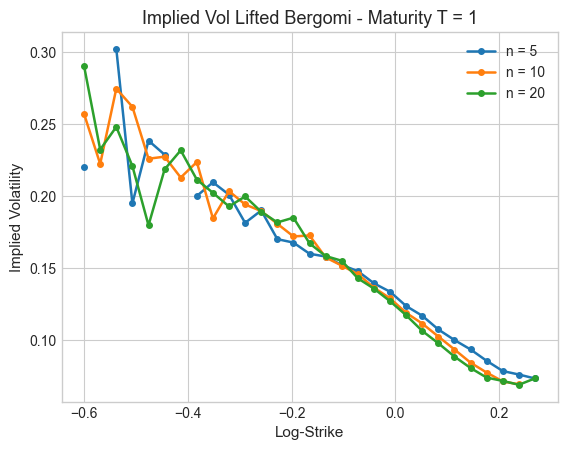

In [ ]:
impl_vol_lt = compute_res(params)
        
log_strikes = np.log(params["K"])
fig, ax = plt.subplots()

for i in range(len(params["n"])):
    ax.plot(log_strikes, impl_vol_lt[i,:], label=f'n = {params["n"][i]}', marker='o', markersize=4, linewidth=1.8)

ax.set_title('Implied Vol Lifted Bergomi - Maturity T = 1', fontsize=13)
ax.set_xlabel('Log-Strike', fontsize=11)
ax.set_ylabel('Implied Volatility', fontsize=11)
plt.legend()
plt.show()

See full explanation and results in corresponding [doc](../docs/lifted_bergomi_iv.md)